# Netflix Content Catalog Analysis
**Business Scenario:** Netflix management wants a comprehensive analysis of its content catalog — country-wise content production, popular directors, content ratings, and genre popularity.

This notebook walks through Data Understanding, Data Cleaning, Feature Engineering, Exploratory Data Analysis, and Monthly Content Addition Anomaly Detection.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Data Understanding

In [2]:
# Load dataset using Pandas
url = "https://raw.githubusercontent.com/allenkong221/netflix-titles-dataset/refs/heads/main/netflix_titles.csv"
df = pd.read_csv(url)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (6234, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [3]:
# Generate descriptive statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,6234.0,NaN,NaN,NaN,76703679.319859,10942964.649885,247747.0,80035801.75,80163367.0,80244888.75,81235729.0
type,6234,2,Movie,4265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,6234,6172,Love,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,4265,3301,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,5664,5469,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5758,554,United States,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,6223,1524,"January 1, 2020",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,6234.0,NaN,NaN,NaN,2013.35932,8.81162,1925.0,2013.0,2016.0,2018.0,2020.0
rating,6224,14,TV-MA,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,6234,201,1 Season,1321,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# List unique value count for columns in the dataframe
unique_counts = df.nunique().sort_values(ascending=False)
unique_counts

show_id         6234
description     6226
title           6172
cast            5469
director        3301
date_added      1524
country          554
listed_in        461
duration         201
release_year      72
rating            14
type               2
dtype: int64

In [5]:
# Basic info about the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  listed_in     6234 non-null   str  
 11  description   6234 non-null   str  
dtypes: int64(2), str(10)
memory usage: 584.6 KB


## Part 2: Data Cleaning

In [6]:
# Find duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df[df.duplicated()]

Number of duplicate rows: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [7]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (6234, 12)


In [8]:
# Check null value count for columns
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

director      1969
cast           570
country        476
date_added      11
rating          10
dtype: int64

In [9]:
# Replace Nulls in Director with "No Director". Similar replacements in Cast, Country
df['director'] = df['director'].fillna("No Director")
df['cast'] = df['cast'].fillna("No Cast")
df['country'] = df['country'].fillna("No Country")

# Confirm replacements
df[['director', 'cast', 'country']].isnull().sum()

director    0
cast        0
country     0
dtype: int64

In [10]:
# Drop records with nulls in date_added & rating columns
df = df.dropna(subset=['date_added', 'rating'])
print("Shape after dropping nulls in date_added & rating:", df.shape)

# Final null check
df.isnull().sum()

Shape after dropping nulls in date_added & rating: (6214, 12)


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## Part 3: Feature Engineering

In [11]:
# Create a dataframe (movies_df) having only movies data (type = 'Movie')
movies_df = df[df['type'] == 'Movie'].copy()
print("Shape of movies_df:", movies_df.shape)
movies_df.head()

Shape of movies_df: (4257, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,No Director,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
6,70304989,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
7,80164077,Movie,Fabrizio Copano: Solo pienso en mi,"Rodrigo Toro, Francisco Schultz",Fabrizio Copano,Chile,"September 8, 2017",2017,TV-MA,60 min,Stand-Up Comedy,Fabrizio Copano takes audience participation t...


In [12]:
# Convert date_added to datetime
movies_df['date_added'] = pd.to_datetime(movies_df['date_added'].str.strip())

# 1. Year Added - Extract from Date Added
movies_df['year_added'] = movies_df['date_added'].dt.year

# 2. Month Added - Extract Month Name from Date Added
movies_df['month_added'] = movies_df['date_added'].dt.month_name()

# 3. Content Age = year_added - release_year
movies_df['content_age'] = movies_df['year_added'] - movies_df['release_year']

# 4. Movie Duration Minutes - Extract the integer value from duration column and cast to int
movies_df['movie_duration_minutes'] = movies_df['duration'].str.extract(r'(\d+)').astype(int)

movies_df[['title', 'year_added', 'month_added', 'content_age', 'movie_duration_minutes']].head(10)

,title,year_added,month_added,content_age,movie_duration_minutes
0,Norm of the North: King Sized Adventure,2019,September,0,90
1,Jandino: Whatever it Takes,2016,September,0,94
4,#realityhigh,2017,September,0,99
6,Automata,2017,September,3,110
7,Fabrizio Copano: Solo pienso en mi,2017,September,0,60
9,Good People,2017,September,3,90
10,Joaquín Reyes: Una y no más,2017,September,0,78
11,Kidnapping Mr. Heineken,2017,September,2,95
12,Krish Trish and Baltiboy,2017,September,8,58
13,Krish Trish and Baltiboy: Battle of Wits,2017,September,4,62


## Part 4: Exploratory Data Analysis
### Netflix Movie Analysis Dashboard

/tmp/ipykernel_550/335433486.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=movies_df, order=rating_order, palette='viridis')


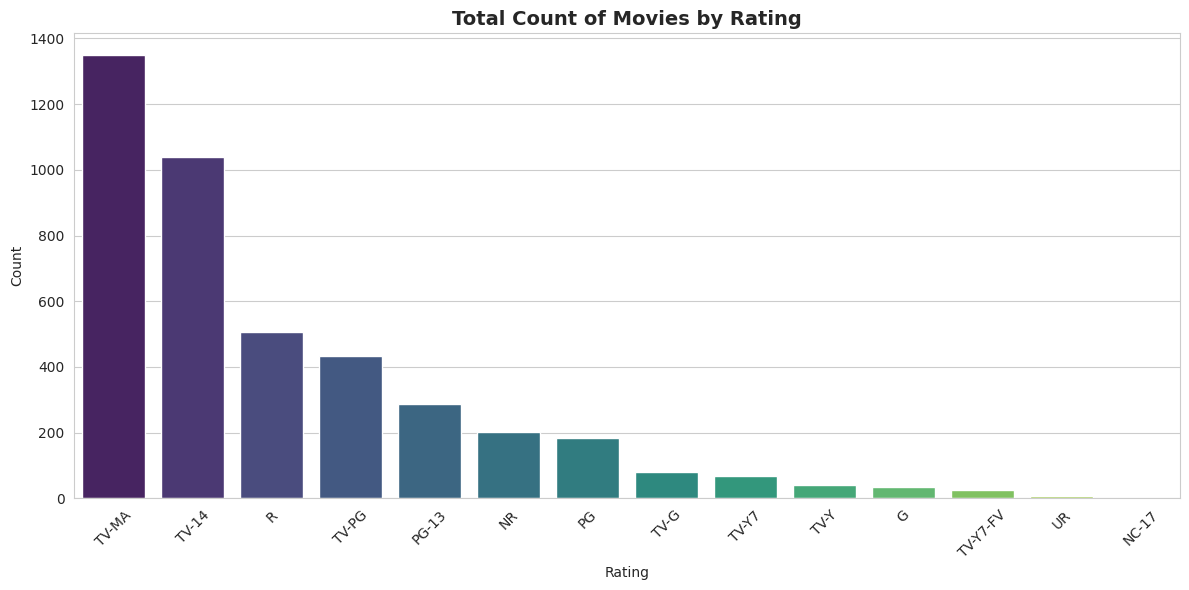

In [13]:
# 1. Total count by ratings as a CountPlot
plt.figure(figsize=(12, 6))
rating_order = movies_df['rating'].value_counts().index
sns.countplot(x='rating', data=movies_df, order=rating_order, palette='viridis')
plt.title('Total Count of Movies by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

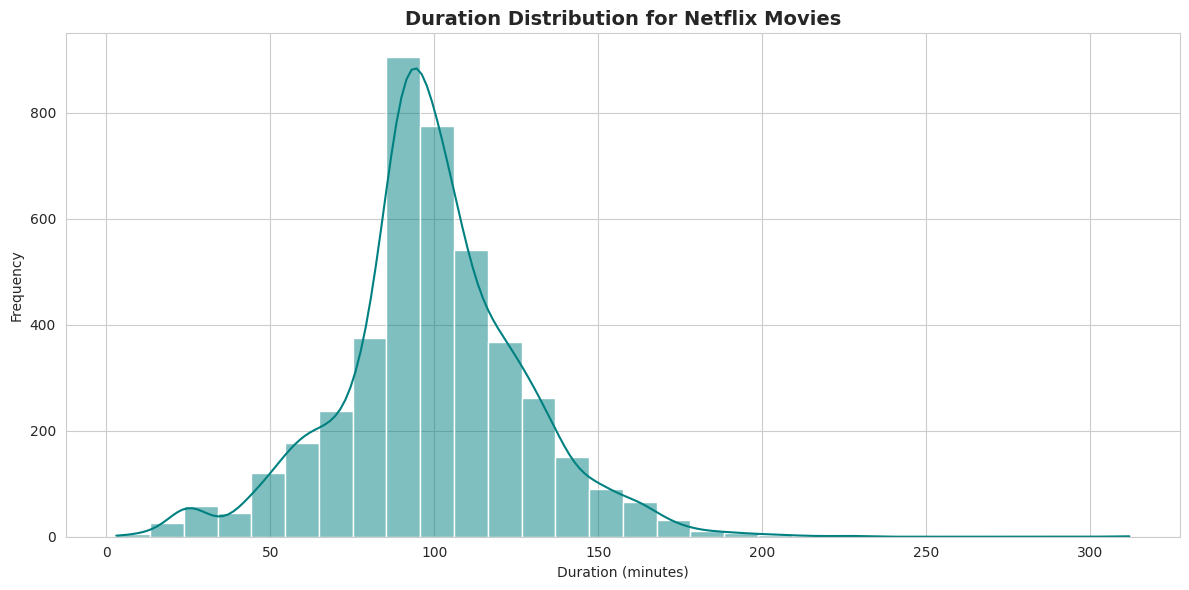

In [14]:
# 2. Duration Distribution for Netflix Movies as a DistPlot
plt.figure(figsize=(12, 6))
sns.histplot(movies_df['movie_duration_minutes'], kde=True, color='teal', bins=30)
plt.title('Duration Distribution for Netflix Movies', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_550/2215413162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_years.index.astype(int), y=top5_years.values, palette='mako')


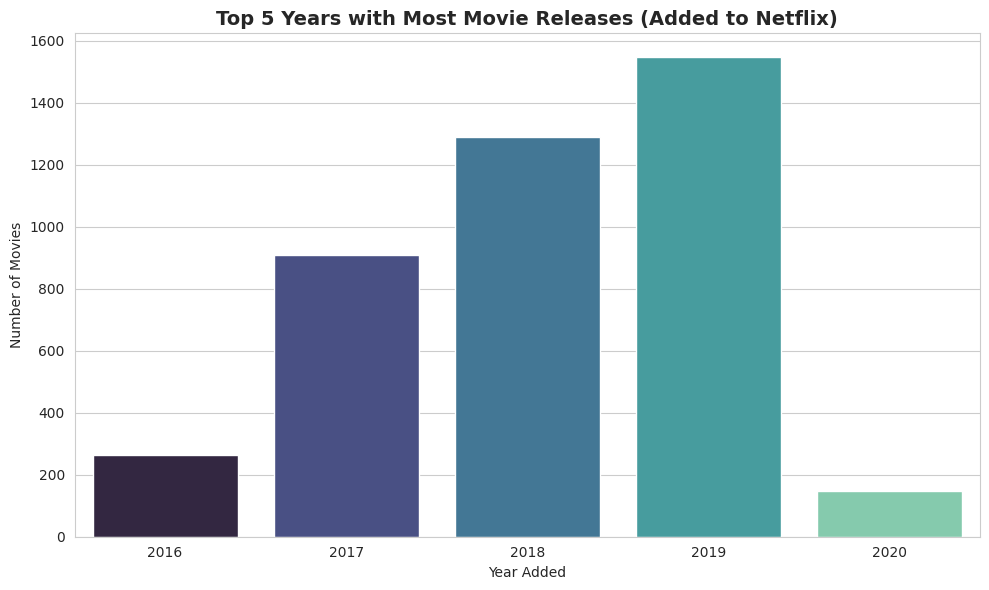

In [15]:
# 3. Top 5 years with most releases as a Bar Plot
top5_years = movies_df['year_added'].value_counts().head(5).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=top5_years.index.astype(int), y=top5_years.values, palette='mako')
plt.title('Top 5 Years with Most Movie Releases (Added to Netflix)', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

/tmp/ipykernel_550/4240355323.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_directors.values, y=top10_directors.index, palette='crest')


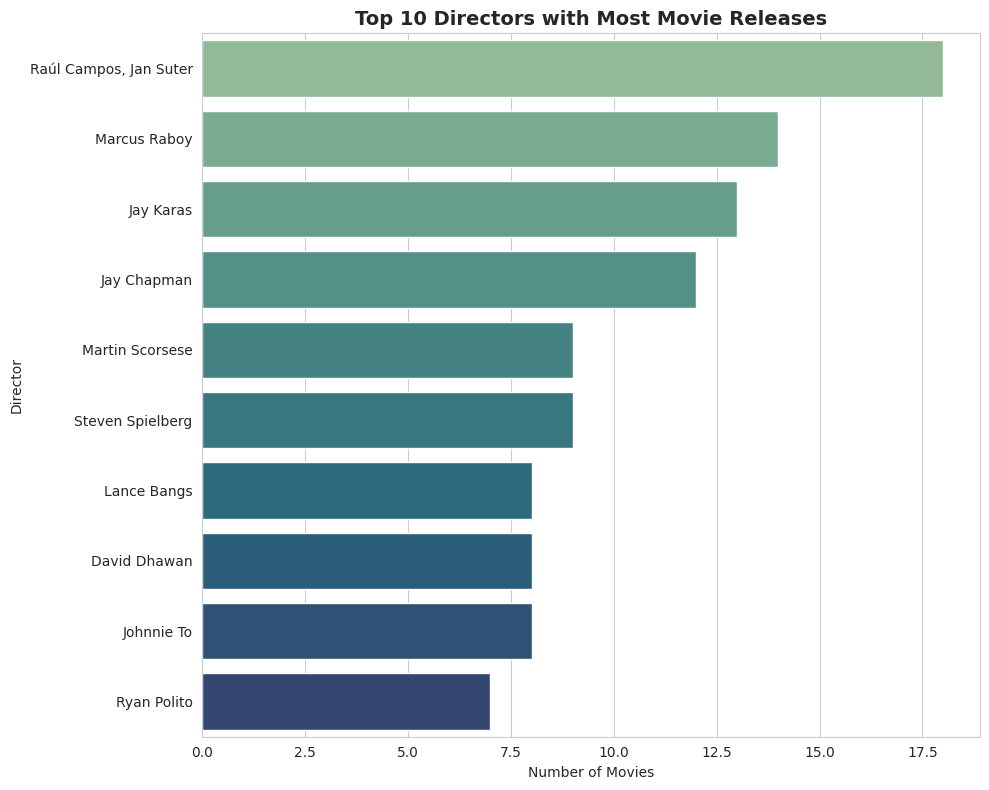

In [16]:
# 4. Top 10 Directors with most releases as a Horizontal Bar Plot
top10_directors = movies_df[movies_df['director'] != 'No Director']['director'].value_counts().head(10)

plt.figure(figsize=(10, 8))
sns.barplot(x=top10_directors.values, y=top10_directors.index, palette='crest')
plt.title('Top 10 Directors with Most Movie Releases', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

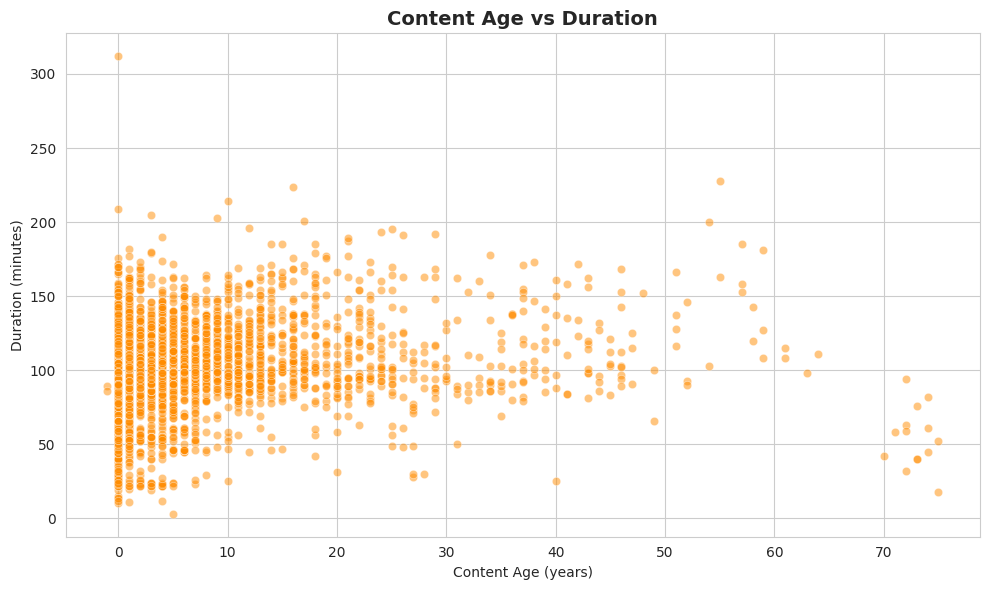

In [17]:
# 5. Content Age vs Duration as a Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='content_age', y='movie_duration_minutes', data=movies_df, alpha=0.5, color='darkorange')
plt.title('Content Age vs Duration', fontsize=14, fontweight='bold')
plt.xlabel('Content Age (years)')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_550/1575257329.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='content_age', data=movies_df, palette='Set2')


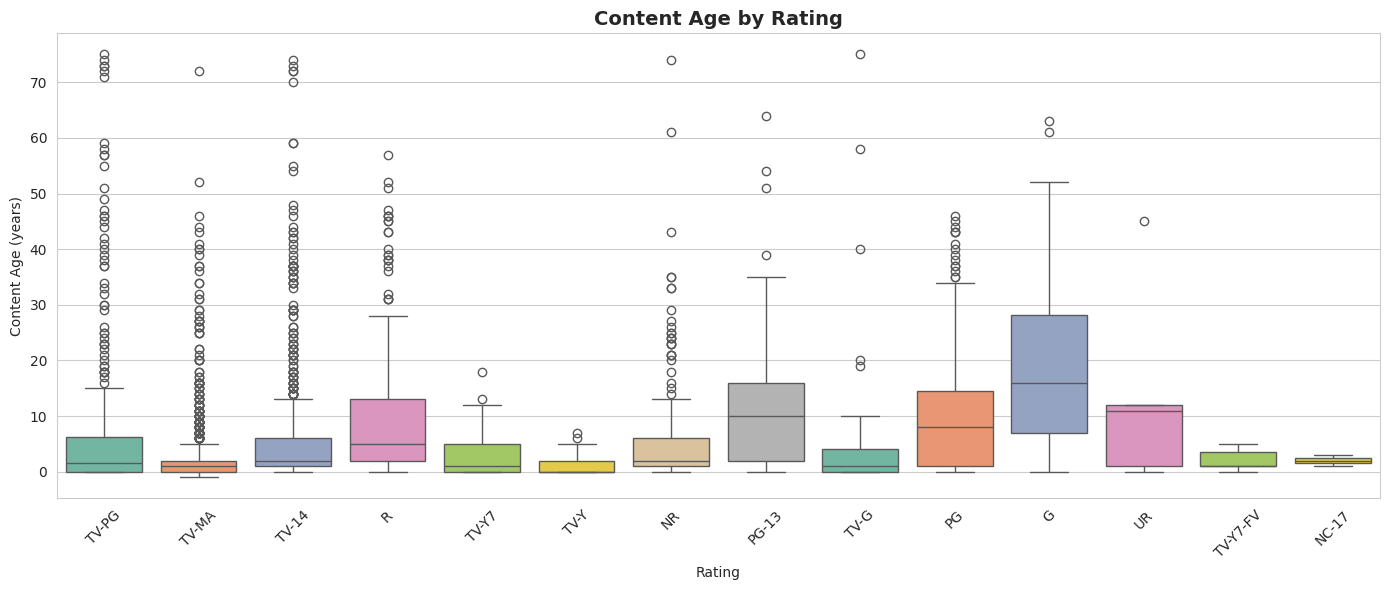

In [18]:
# 6. Content age by rating as a Box Plot
plt.figure(figsize=(14, 6))
sns.boxplot(x='rating', y='content_age', data=movies_df, palette='Set2')
plt.title('Content Age by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Content Age (years)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 5: Monthly Content Addition Anomaly Detection
Find months where Netflix added unusually high or low volumes of content (Movies + TV Shows), detect outliers using Z-score, and visualize monthly trends along with outliers.

In [19]:
# Prepare monthly content addition counts (across all content types)
monthly_df = df.copy()
monthly_df['date_added'] = pd.to_datetime(monthly_df['date_added'].str.strip())
monthly_df['year_month'] = monthly_df['date_added'].dt.to_period('M')

monthly_trend = monthly_df.groupby('year_month').size().reset_index(name='count')
monthly_trend['year_month_str'] = monthly_trend['year_month'].astype(str)
monthly_trend.head()

,year_month,count,year_month_str
0,2008-01,1,2008-01
1,2008-02,1,2008-02
2,2009-05,1,2009-05
3,2009-11,1,2009-11
4,2010-11,1,2010-11


In [20]:
# Detect outliers using Z-score
monthly_trend['z_score'] = stats.zscore(monthly_trend['count'])

# Flag months where |z-score| > 2 as anomalies (unusually high or low)
monthly_trend['is_outlier'] = monthly_trend['z_score'].abs() > 2

outliers = monthly_trend[monthly_trend['is_outlier']]
print(f"Number of anomalous months detected: {len(outliers)}")
outliers[['year_month_str', 'count', 'z_score']]

Number of anomalous months detected: 2


,year_month_str,count,z_score
89,2019-11,292,2.923212
90,2019-12,232,2.141802


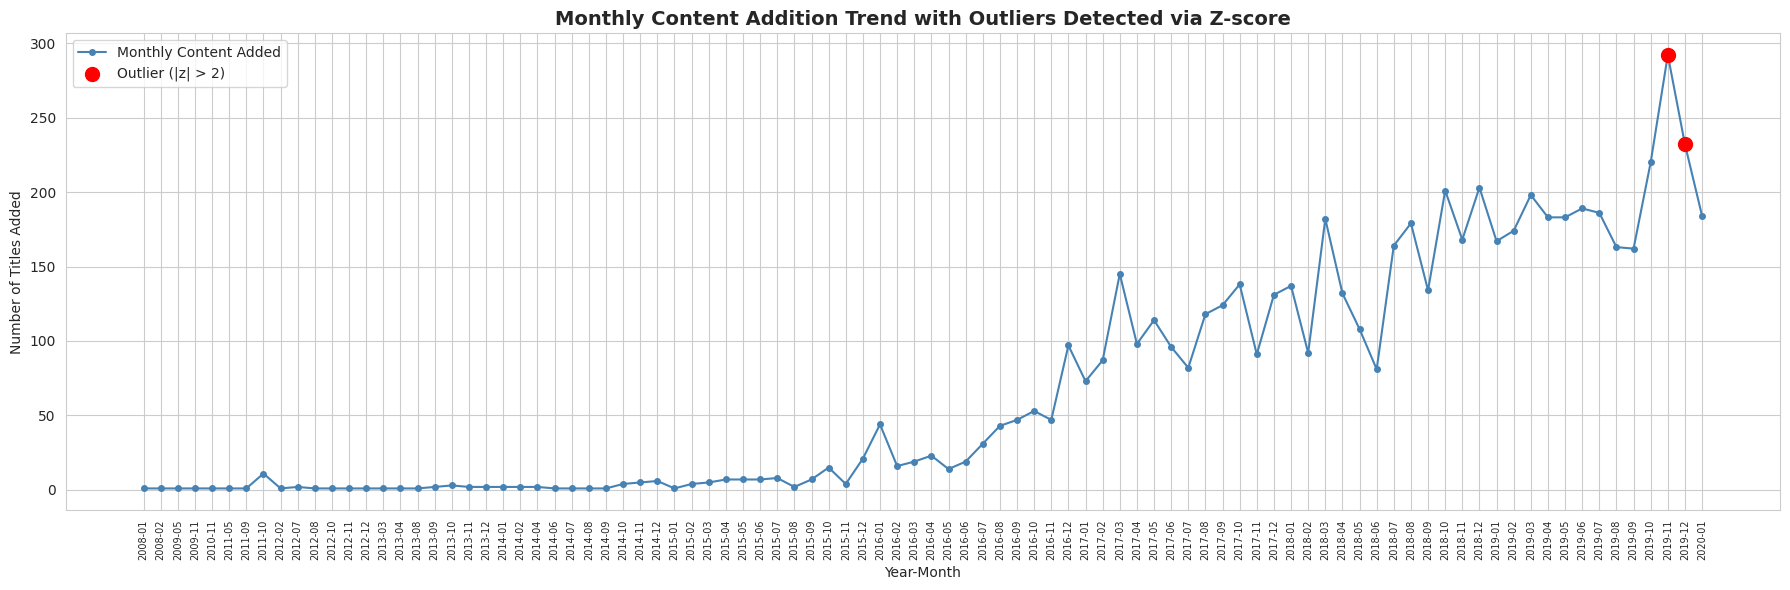

In [21]:
# Visualize monthly trends along with outliers
plt.figure(figsize=(18, 6))
plt.plot(monthly_trend['year_month_str'], monthly_trend['count'], marker='o', color='steelblue',
         label='Monthly Content Added', linewidth=1.5, markersize=4)

# Highlight outliers
outlier_points = monthly_trend[monthly_trend['is_outlier']]
plt.scatter(outlier_points['year_month_str'], outlier_points['count'], color='red', s=100,
            zorder=5, label='Outlier (|z| > 2)')

plt.title('Monthly Content Addition Trend with Outliers Detected via Z-score', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()

### Summary
- The dashboard above surfaces rating distribution, duration patterns, top release years, top directors, and the relationship between content age, duration, and rating.
- The anomaly detection step flags calendar months where Netflix's content-addition volume deviated significantly (Z-score > 2 in absolute value) from the overall monthly average, highlighting unusually large content pushes.